# Transformée de Laplace 4D de $e^{-at} \cos(bt) u(t)$

Transformée de Laplace :
$$
X(s) = \frac{s+a}{(s+a)^2+b^2}
$$

zéro en $s = -a$ et pôles en $s = -a+jb$ et $s = -a-jb$

Transformée de Fourier ($w = 2*\pi*f$) :
$$
X(f) = \frac{a+jw}{a^2+b^2-w^2+j*2*a*w)}
$$

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import cm
import numpy as np
from numpy import pi
plt.style.use('../../src/signal.mplstyle')

In [2]:
# Fonction temporelle x(t)
a = 1
b = 1*2*pi

# variable de Fourier
w = np.arange(-10, 10.5, .5)

# parties réelle et imaginaire de la variable de Laplace
sigma, omega = np.meshgrid(w,w)

# variable de Laplace
s = sigma + 1j*omega

# indice où sigma = 0
i = np.where(w==0)

# Transformée de Laplace
Xs = (s+a) / ((s+a)**2+b**2)
G = 20*np.log10(np.abs(Xs))
G = np.where(G<-40, -40, G)
P = np.angle(Xs)

# Transformée de Fourier
Xf = (1j*w+a) / ((1j*w+a)**2+b**2)

/tmp/ipykernel_11068/2146146290.py:19: RuntimeWarning: divide by zero encountered in log10
  G = 20*np.log10(np.abs(Xs))


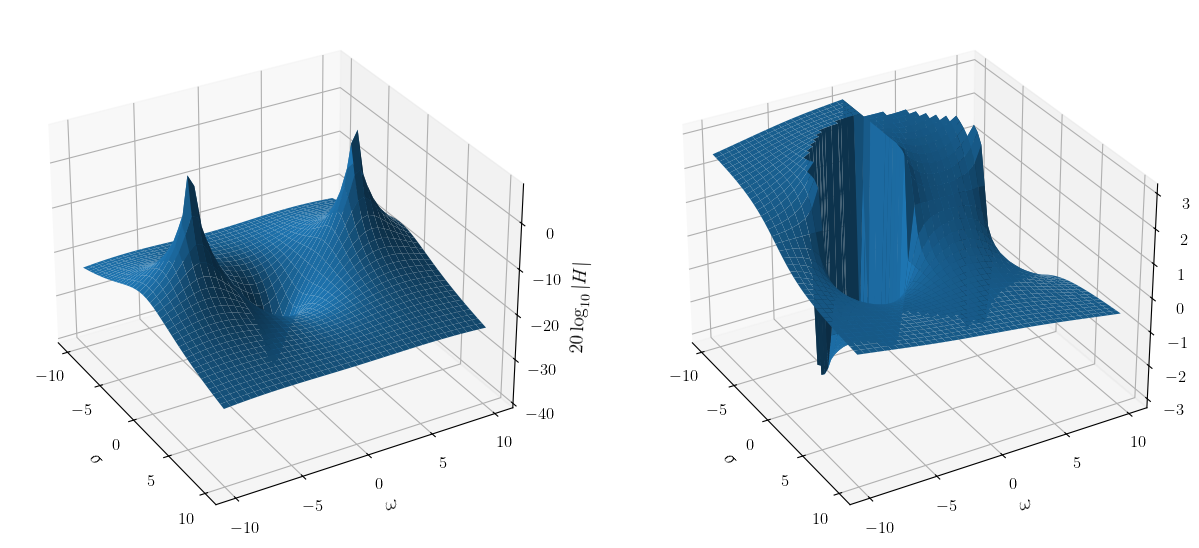

In [3]:
# Transformée de Laplace
fig = plt.figure(figsize=(15,7))
elev = 30
azim = -30
xx = np.arange(-10, 10.5, 5)

# Module
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot_surface(sigma, omega, G)
ax.view_init(elev=elev, azim=azim)
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$\omega$')
ax.set_zlabel(r'$20\log_{10}|H|$')
ax.set_xticks(xx)
ax.set_yticks(xx)

# Argument
ax = fig.add_subplot(1, 2, 2, projection='3d')
surf = ax.plot_surface(sigma, omega, P)
ax.view_init(elev=elev, azim=azim)
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$\omega$')
ax.set_zlabel(r'$\mathrm{Arg}(H)$')
ax.set_xticks(xx)
ax.set_yticks(xx)

plt.savefig("laplace4d.svg")
plt.savefig("laplace4d.png")
plt.show()

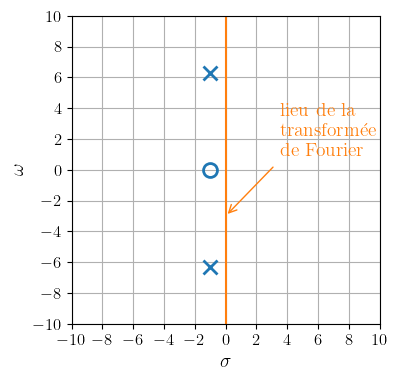

In [4]:
# Graphe Pôle-zéros
fig, ax = plt.subplots(1, 1, figsize=(4,4))
ax.set_aspect('equal')

ax.set_xticks(np.arange(-10, 11, 2))
ax.set_xlim([-10, 10])
ax.set_yticks(np.arange(-10, 11, 2))
ax.set_ylim([-10, 10])
    
ax.plot(-a, 0, marker='o', markersize=10, color='tab:blue', markeredgewidth=2, fillstyle='none')
ax.plot(-a, b, marker='x', markersize=10, color='tab:blue', markeredgewidth=2)
ax.plot(-a,-b, marker='x', markersize=10, color='tab:blue', markeredgewidth=2)

ax.plot([0, 0],[-10, 10], color='tab:orange', linewidth=1.5)
ax.annotate(text='', xytext=(3.2,0.3), xy=(0,-3), arrowprops=dict(arrowstyle='->', color="tab:orange"))
ax.text(3.5, 2.5, "lieu de la\ntransformée\nde Fourier", ha="left", va="center", color="tab:orange")

ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$\omega$')

plt.savefig("diagpz.svg")
plt.savefig("diagpz.png")
plt.show()